In [1]:
!pip install -q xgboost lightgbm catboost optuna

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import optuna

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression

# Модели
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier, Pool

# Отключаем лишние предупреждения
import warnings
warnings.filterwarnings('ignore')

# Стиль для графиков
plt.style.use('seaborn-v0_8-whitegrid')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 10.9 MB/s eta 0:00:00


## Датасет

In [2]:
# Используем датасет о предсказании оттока клиентов телеком-оператора.
!wget -q https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv -O telco.csv

df = pd.read_csv('telco.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [4]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['MonthlyCharges'] = pd.to_numeric(df['MonthlyCharges'], errors='coerce')
df.dropna(inplace=True)
df.drop('customerID', axis=1, inplace=True)
df['Churn'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# Явно определим типы признаков
cat_features_names = df.select_dtypes(include=['object']).columns.tolist()
num_features_names = df.select_dtypes(include=np.number).drop('Churn', axis=1).columns.tolist()

X = df.drop('Churn', axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

print("Данные загружены. Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)

Данные загружены. Размер обучающей выборки: (5274, 19)
Размер тестовой выборки: (1758, 19)


In [5]:
# Создаем копии, чтобы не изменять оригинальные данные
X_train_base, X_test_base = X_train.copy(), X_test.copy()

# One-Hot Encoding
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_cat_encoded = encoder.fit_transform(X_train_base[cat_features_names])
X_test_cat_encoded = encoder.transform(X_test_base[cat_features_names])

# Соединяем
X_train_processed = np.hstack((X_train_cat_encoded, X_train_base[num_features_names].values))
X_test_processed = np.hstack((X_test_cat_encoded, X_test_base[num_features_names].values))

## Ансамбли

Обучение с learning_rate = 0.3...
  -> Лучшая итерация: 3, Лучший AUC: 0.8358

Обучение с learning_rate = 0.1...
  -> Лучшая итерация: 7, Лучший AUC: 0.8386

Обучение с learning_rate = 0.01...
  -> Лучшая итерация: 102, Лучший AUC: 0.8374

Обучение с learning_rate = 0.001...
  -> Лучшая итерация: 296, Лучший AUC: 0.8343



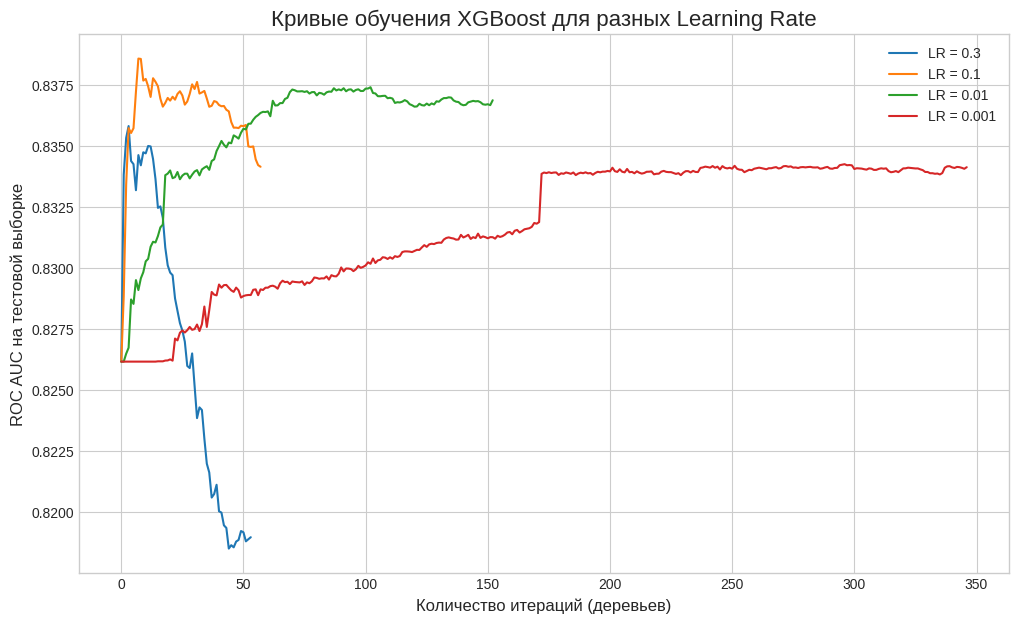

In [8]:
# Мы обучим три модели XGBoost с разным learning_rate, но с ОЧЕНЬ большим
# количеством деревьев и ранней остановкой.
# Цель: Показать, что чем ниже learning_rate, тем больше итераций нужно,
# и тем потенциально более точную модель можно получить.

# Используем тот же OHE-датасет, что и для логистической регрессии
eval_set = [(X_test_processed, y_test)]
learning_rates = [0.3, 0.1, 0.01, 0.001]
results = {}

plt.figure(figsize=(12, 7))

for lr in learning_rates:
    print(f"Обучение с learning_rate = {lr}...")

    model = XGBClassifier(
        n_estimators=2000,
        learning_rate=lr,
        random_state=42,
        n_jobs=-1,
        eval_metric='auc',
        early_stopping_rounds=50
    )

    model.fit(
        X_train_processed, y_train,
        eval_set=eval_set,
        verbose=False
    )

    # Сохраняем историю обучения
    train_log = model.evals_result()['validation_0']['auc']
    results[lr] = train_log

    print(f"  -> Лучшая итерация: {model.best_iteration}, Лучший AUC: {model.best_score:.4f}\n")

    # Рисуем график
    plt.plot(range(len(train_log)), train_log, label=f'LR = {lr}')

plt.title('Кривые обучения XGBoost для разных Learning Rate', fontsize=16)
plt.xlabel('Количество итераций (деревьев)', fontsize=12)
plt.ylabel('ROC AUC на тестовой выборке', fontsize=12)
plt.legend()
plt.show()

# На практике обычно работает следующее:
# "низкий learning_rate (0.01-0.05) + высокий n_estimators (1000+) + early_stopping_rounds".

Градиентный бустинг подвержен переобучению сильнее, чем его "брат" Random Forest.

In [10]:
# Модель без регуляризации

eval_set = [(X_train_processed, y_train)]

xgb_overfit = XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=10, random_state=42, eval_metric='auc')

xgb_overfit.fit(X_train_processed, y_train, eval_set=eval_set, verbose=False)
auc_overfit_train = roc_auc_score(y_train, xgb_overfit.predict_proba(X_train_processed)[:, 1])
auc_overfit_test = roc_auc_score(y_test, xgb_overfit.predict_proba(X_test_processed)[:, 1])
print(f"Без регуляризации: Train AUC = {auc_overfit_train:.4f}, Test AUC = {auc_overfit_test:.4f}")
print(f"Разрыв (переобучение): {auc_overfit_train - auc_overfit_test:.4f}\n")

# results_overfit = xgb_overfit.evals_result()
# train_auc_overfit = results_overfit['validation_0']['auc']
# test_auc_overfit = results_overfit['validation_1']['auc']

Без регуляризации: Train AUC = 0.9984, Test AUC = 0.8087
Разрыв (переобучение): 0.1897



`gamma` (min_split_loss): Узел будет расщеплен, только если это приведет к уменьшению
  функции потерь больше, чем на значение gamma. По сути, это "штраф" за сложность дерева.
  
`reg_lambda` (L2): Штрафует большие веса в листьях деревьев, делая модель более гладкой и устойчивой.

In [11]:
# Модель с сильной регуляризацией
xgb_regularized = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=10,
    gamma=5,             # достаточно высокий gamma
    reg_lambda=10,       # L2 регуляризация
    random_state=42,
    eval_metric='auc'
)

xgb_regularized.fit(X_train_processed, y_train, eval_set=eval_set, verbose=False)
auc_reg_train = roc_auc_score(y_train, xgb_regularized.predict_proba(X_train_processed)[:, 1])
auc_reg_test = roc_auc_score(y_test, xgb_regularized.predict_proba(X_test_processed)[:, 1])
print(f"С регуляризацией: Train AUC = {auc_reg_train:.4f}, Test AUC = {auc_reg_test:.4f}")
print(f"Разрыв (переобучение): {auc_reg_train - auc_reg_test:.4f}")

# results_regularized = xgb_regularized.evals_result()
# train_auc_regularized = results_regularized['validation_0']['auc']
# test_auc_regularized = results_regularized['validation_1']['auc']

С регуляризацией: Train AUC = 0.8691, Test AUC = 0.8469
Разрыв (переобучение): 0.0222


NameError: name 'test_auc_overfit' is not defined

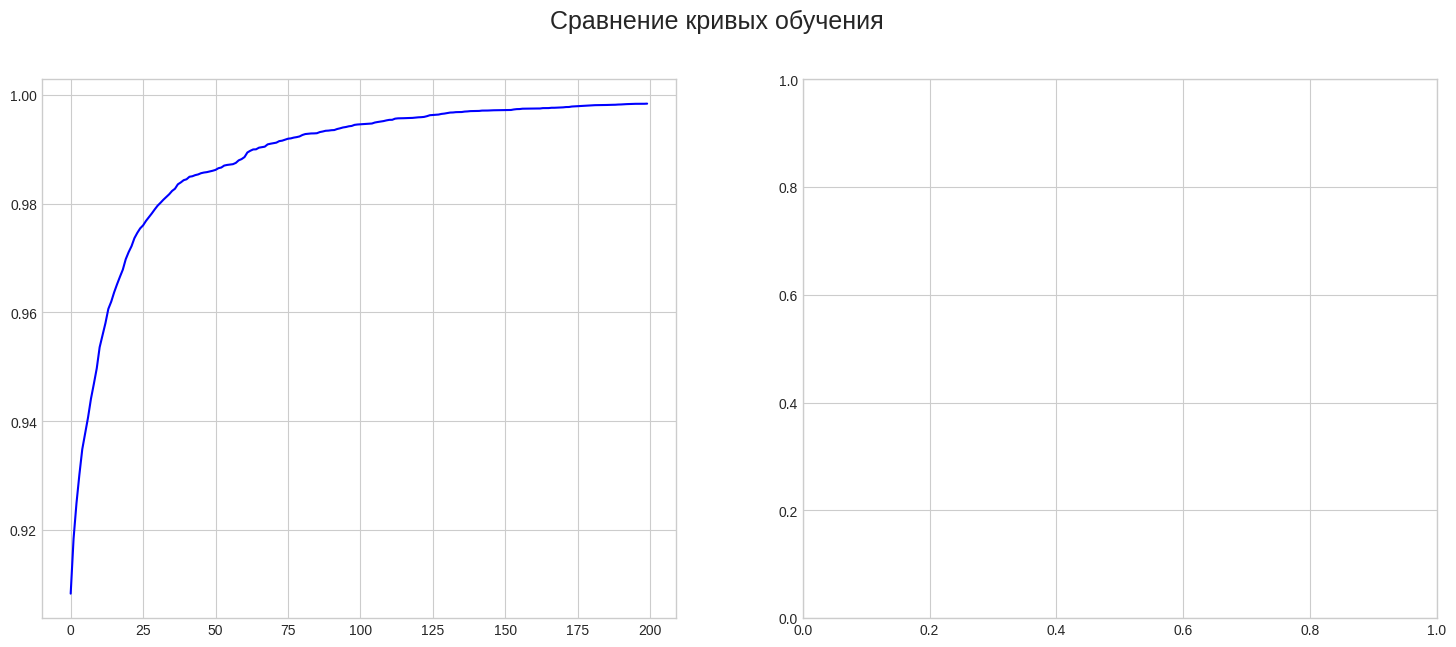

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Сравнение кривых обучения', fontsize=18)

# График для модели без регуляризации
ax1.plot(train_auc_overfit, label='Train AUC', color='blue')
ax1.plot(test_auc_overfit, label='Test AUC', color='orange')
ax1.set_title('Без регуляризации', fontsize=14)
ax1.set_xlabel('Количество итераций', fontsize=12)
ax1.set_ylabel('ROC AUC', fontsize=12)

# Находим точку, где начинается переобучение (максимум на тесте)
best_iteration_overfit = np.argmax(test_auc_overfit)
ax1.axvline(x=best_iteration_overfit, color='r', linestyle='--', label=f'Точка переобучения (~{best_iteration_overfit} итераций)')
ax1.legend()

# График для модели с регуляризацией
ax2.plot(train_auc_regularized, label='Train AUC', color='blue')
ax2.plot(test_auc_regularized, label='Test AUC', color='orange')
ax2.set_title('С регуляризацией', fontsize=14)
ax2.set_xlabel('Количество итераций', fontsize=12)
ax2.set_ylabel('ROC AUC', fontsize=12)
ax2.legend()

plt.show()

Регуляризация снизила качество на трейне (это нормально!), но значительно уменьшила разрыв между трейном и тестом. Модель стала менее подогнанной под обучающие данные и лучше обобщает на новых данных.

## Разные реализации градиентного бустинга

Мы сравним 3 подхода на одной и той же задаче:
1. XGBoost + OneHotEncoder: Классический, но громоздкий способ. В нашей задаче это не так заметно, но в рабочих пайплайнах, где данные приходится очень круто вертеть, можно запутаться.
2. LightGBM + astype('category'): Быстрый нативный способ.
3. CatBoost + cat_features: Самый продвинутый и безопасный способ.

In [13]:
start_time = time.time()

xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss').fit(X_train_processed, y_train)
xgb_auc = roc_auc_score(y_test, xgb.predict_proba(X_test_processed)[:, 1])

xgb_time = time.time() - start_time

print(f"1. XGBoost + OHE: AUC = {xgb_auc:.4f}, Время = {xgb_time:.2f} сек.")
print(f"Количество признаков после OHE: {X_train_processed.shape[1]}")

1. XGBoost + OHE: AUC = 0.8167, Время = 0.24 сек.
Количество признаков после OHE: 45


In [14]:
X_train_lgbm, X_test_lgbm = X_train.copy(), X_test.copy()
for col in cat_features_names:
    X_train_lgbm[col] = X_train_lgbm[col].astype('category')
    X_test_lgbm[col] = X_test_lgbm[col].astype('category')

start_time = time.time()

lgbm = LGBMClassifier(random_state=42, verbose=0).fit(X_train_lgbm, y_train)
lgbm_auc = roc_auc_score(y_test, lgbm.predict_proba(X_test_lgbm)[:, 1])

lgbm_time = time.time() - start_time
print(f"2. LightGBM: AUC = {lgbm_auc:.4f}, Время = {lgbm_time:.2f} сек.")

2. LightGBM: AUC = 0.8303, Время = 0.25 сек.


In [16]:
start_time = time.time()
cat = CatBoostClassifier(random_seed=42, verbose=0, cat_features=cat_features_names).fit(X_train, y_train)
cat_auc = roc_auc_score(y_test, cat.predict_proba(X_test)[:, 1])
cat_time = time.time() - start_time
print(f"3. CatBoost (нативный): AUC = {cat_auc:.4f}, Время = {cat_time:.2f} сек.")

3. CatBoost (нативный): AUC = 0.8378, Время = 18.73 сек.


OHE для XGBoost работает, но "раздувает" количество признаков.
LightGBM и CatBoost работают с исходными данными, что быстрее и эффективнее с точки зрения памяти.
Они используют свои внутренние, более умные, методы кодирования, что часто приводит к лучшему качеству (как мы видим, CatBoost и LightGBM немного обошли XGBoost).

## Автоподбор гиперпараметров

Для подбора гиперпараметров моделей обычно используется библиотека optuna.

In [17]:
# Optuna будет "умно" перебирать комбинации параметров, чтобы максимизировать нашу метрику
# Мы будем использовать кросс-валидацию, чтобы получить надежную оценку качества.

def objective(trial):
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'n_estimators': 1000,
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),  # аналог bagging_fraction
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0)  # аналог feature_fraction
    }

    # Для LGBM нужны данные с типом 'category'
    X_train_lgbm, _ = X_train.copy(), X_test.copy()
    for col in cat_features_names:
        X_train_lgbm[col] = X_train_lgbm[col].astype('category')

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    cv_scores = np.empty(3)

    # Early stopping callback
    early_stopping = __import__('lightgbm').early_stopping(50, verbose=False)

    for idx, (train_idx, val_idx) in enumerate(cv.split(X_train_lgbm, y_train)):
        X_train_fold, X_val_fold = X_train_lgbm.iloc[train_idx], X_train_lgbm.iloc[val_idx]
        y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = LGBMClassifier(**params)
        model.fit(X_train_fold, y_train_fold,
                  eval_set=[(X_val_fold, y_val_fold)],
                  eval_metric='auc',
                  callbacks=[early_stopping])

        preds = model.predict_proba(X_val_fold)[:, 1]
        cv_scores[idx] = roc_auc_score(y_val_fold, preds)

    return np.mean(cv_scores)

study = optuna.create_study(direction='maximize', study_name='LGBM Optimization')
study.optimize(objective, n_trials=50, show_progress_bar=True)  # 50 попыток найти лучшие параметры

print("\nОптимизация завершена!")
print("Лучшее значение (AUC на CV):", study.best_value)
print("Лучшие гиперпараметры:", study.best_params)

[I 2026-03-05 16:50:55,588] A new study created in memory with name: LGBM Optimization


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-03-05 16:50:56,641] Trial 0 finished with value: 0.8410645288931414 and parameters: {'learning_rate': 0.0010152012058208888, 'num_leaves': 197, 'max_depth': 7, 'subsample': 0.8551693402602143, 'colsample_bytree': 0.8174601490943423}. Best is trial 0 with value: 0.8410645288931414.
[I 2026-03-05 16:50:57,567] Trial 1 finished with value: 0.8441008275323213 and parameters: {'learning_rate': 0.055229406453194296, 'num_leaves': 91, 'max_depth': 10, 'subsample': 0.9805124350163898, 'colsample_bytree': 0.635609213983501}. Best is trial 1 with value: 0.8441008275323213.
[I 2026-03-05 16:51:00,397] Trial 2 finished with value: 0.8414749111548651 and parameters: {'learning_rate': 0.002530089041458886, 'num_leaves': 44, 'max_depth': 10, 'subsample': 0.7737456286187405, 'colsample_bytree': 0.8840001434675722}. Best is trial 1 with value: 0.8441008275323213.
[I 2026-03-05 16:51:01,192] Trial 3 finished with value: 0.8497487305963239 and parameters: {'learning_rate': 0.033243213690765626, '

In [18]:
best_params = study.best_params
# Добавляем n_estimators, т.к. в objective мы его не подбирали
best_params['n_estimators'] = 1000
best_params['random_state'] = 42

final_lgbm = LGBMClassifier(**best_params)

# Готовим данные
X_train_lgbm, X_test_lgbm = X_train.copy(), X_test.copy()
for col in cat_features_names:
    X_train_lgbm[col] = X_train_lgbm[col].astype('category')
    X_test_lgbm[col] = X_test_lgbm[col].astype('category')

# Обучаем с early stopping на тестовой выборке
final_lgbm.fit(X_train_lgbm, y_train,
               eval_set=[(X_test_lgbm, y_test)],
               eval_metric='auc',
               callbacks=[__import__('lightgbm').early_stopping(50, verbose=False)])

final_auc = roc_auc_score(y_test, final_lgbm.predict_proba(X_test_lgbm)[:, 1])

print(f"LGBM (дефолтный) AUC: {lgbm_auc:.4f}")
print(f"LGBM (Optuna) AUC: {final_auc:.4f}")

LGBM (дефолтный) AUC: 0.8303
LGBM (Optuna) AUC: 0.8446


In [19]:
print(classification_report(y_test, final_lgbm.predict(X_test_lgbm)))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1291
           1       0.66      0.50      0.57       467

    accuracy                           0.80      1758
   macro avg       0.75      0.70      0.72      1758
weighted avg       0.79      0.80      0.79      1758



## Baseline: Логистическая регрессия

А теперь давайте посмотрим, что нам выдаст простая логистическая регрессия с One-Hot Encoding

In [20]:
logreg = LogisticRegression(max_iter=200, random_state=42)
logreg.fit(X_train_processed, y_train)
y_pred_logreg = logreg.predict_proba(X_test_processed)[:, 1]
y_pred = logreg.predict(X_test_processed)

baseline_auc = roc_auc_score(y_test, y_pred_logreg)

print(f"Baseline ROC AUC (Логистическая регрессия): {baseline_auc:.4f}")

Baseline ROC AUC (Логистическая регрессия): 0.8400


In [21]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1291
           1       0.65      0.58      0.61       467

    accuracy                           0.80      1758
   macro avg       0.75      0.73      0.74      1758
weighted avg       0.80      0.80      0.80      1758



:)

## Feature Importance

In [22]:
feature_names = encoder.get_feature_names_out(cat_features_names).tolist() + num_features_names

model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
model.fit(X_train_processed, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

Расчет встроенной важности признаков.

Это самый быстрый и простой способ, но и самый "наивный".

**Принцип**: XGBoost по умолчанию использует метрику "gain" (прирост). Каждый раз, когда модель использует признак для разделения узла в дереве, она измеряет, насколько сильно это разделение уменьшило ошибку. Важность признака — это средний прирост, который дают все разделения по этому признаку во всех деревьях ансамбля.


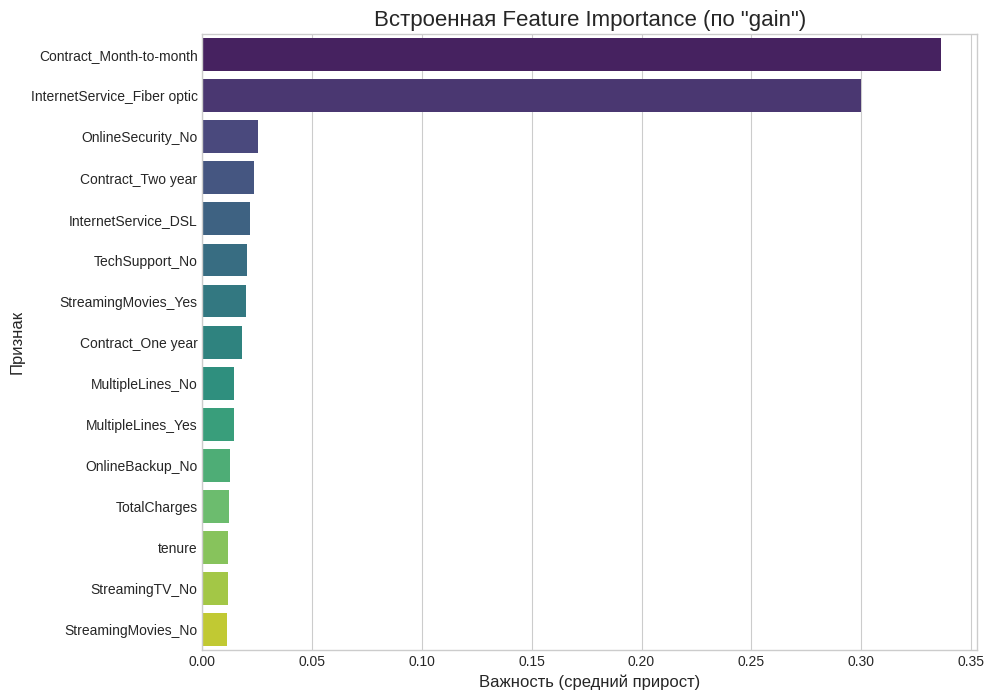

In [23]:
# Расчет и визуализация встроенной важности
# Создаем DataFrame для удобства
builtin_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance_gain': model.feature_importances_
}).sort_values('importance_gain', ascending=False).head(15) # Возьмем топ-15

# Визуализация
plt.figure(figsize=(10, 8))
sns.barplot(x='importance_gain', y='feature', data=builtin_importance_df, palette='viridis')
plt.title('Встроенная Feature Importance (по "gain")', fontsize=16)
plt.xlabel('Важность (средний прирост)', fontsize=12)
plt.ylabel('Признак', fontsize=12)
plt.show()

**Минусы**:
- Смещение: Может быть смещен в сторону числовых признаков или категориальных признаков с большим количеством уникальных значений.
- Не говорит о влиянии: Не показывает, как именно признак влияет на предсказание (повышает или понижает вероятность).


Permutation Importance (Важность по перестановкам)

Это более надежный и интуитивно понятный метод, который измеряет реальное влияние признака на качество модели.

**Принцип**: Мы измеряем, насколько сильно "сломается" модель, если мы "испортим" один из признаков.

**Алгоритм**:
Считаем базовое качество модели (например, ROC AUC) на тестовой (или валидационной) выборке.
Для каждого признака:
1. Случайно перемешиваем значения только этого признака в тестовой выборке. Это разрывает связь между признаком и целевой переменной, сохраняя при этом его распределение.
2. Делаем предсказания на этих "испорченных" данных.
3. Считаем новое, ухудшенное качество.
Важность признака — это разница между базовым и ухудшенным качеством.
Ключевой вопрос, на который он отвечает: "Насколько сильно упадет качество предсказаний модели, если она потеряет доступ к информации из этого признака?"


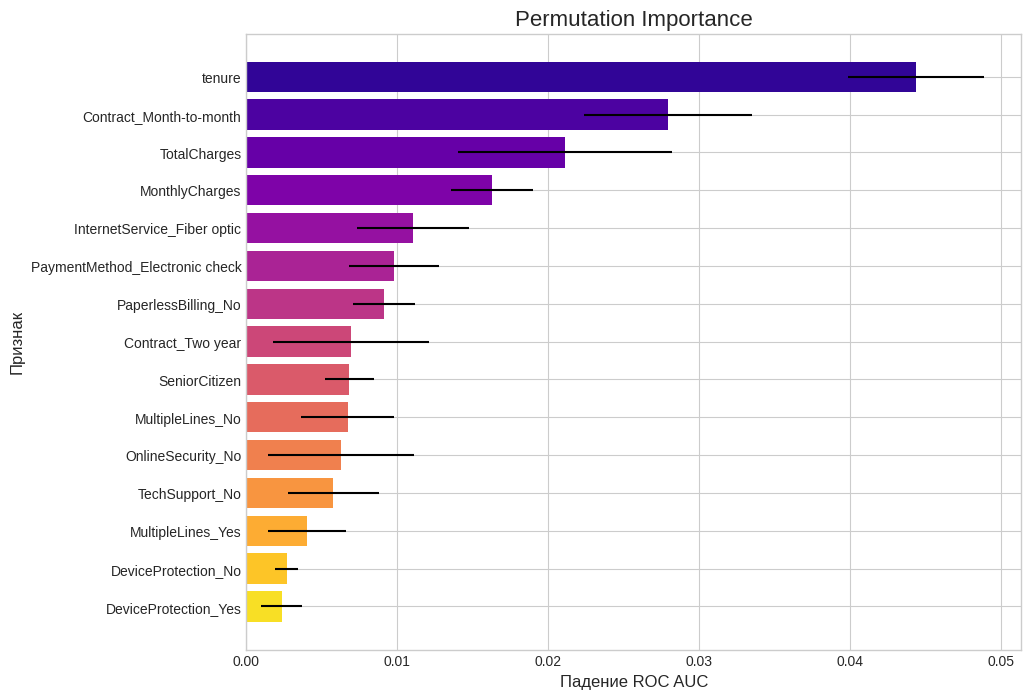

In [24]:
from sklearn.inspection import permutation_importance

# n_repeats > 1 делает оценку более стабильной
perm_importance = permutation_importance(
    model, X_test_processed, y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# Создаем DataFrame
perm_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False).head(15)

# Визуализация
plt.figure(figsize=(10, 8))
plt.barh(perm_importance_df['feature'], perm_importance_df['importance_mean'],
         xerr=perm_importance_df['importance_std'], color=sns.color_palette('plasma', 15))
plt.title('Permutation Importance', fontsize=16)
plt.xlabel('Падение ROC AUC', fontsize=12)
plt.ylabel('Признак', fontsize=12)
plt.gca().invert_yaxis()
plt.show()

**Плюсы:**
*   Надежность: Напрямую измеряет влияние на метрику качества.
*   Этот подход работает для любой модели (от регрессии до нейросетей).

**Минусы:**
*   Вычислительно затратно: Требует многократных предсказаний на тестовой выборке.
*   Проблема с коррелирующими признаками: Если два признака сильно коррелируют, важность каждого из них по отдельности может быть занижена.

SHAP (SHapley Additive exPlanations)**

Это самый продвинутый и информативный метод, основанный на теории игр.


**Принцип:** SHAP объясняет предсказание для каждого отдельного объекта как сумму вкладов от каждого признака.

**Расчет:** Для каждого объекта и каждого признака вычисляется SHAP value— значение, показывающее, как этот признак сдвинул предсказание от среднего по всей выборке.

**Глобальная важность:** Чтобы получить общую важность признака, мы берем среднее абсолютное SHAP value по всем объектам.


График 1: Глобальная важность


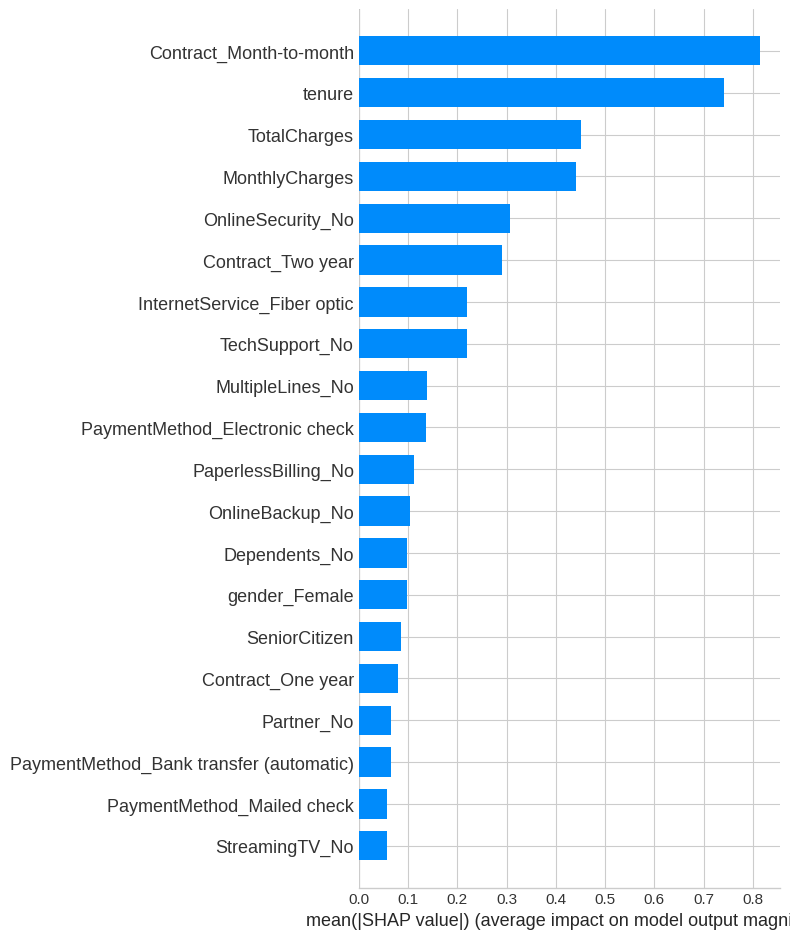


График 2: Распределение влияния признаков (Beeswarm plot)


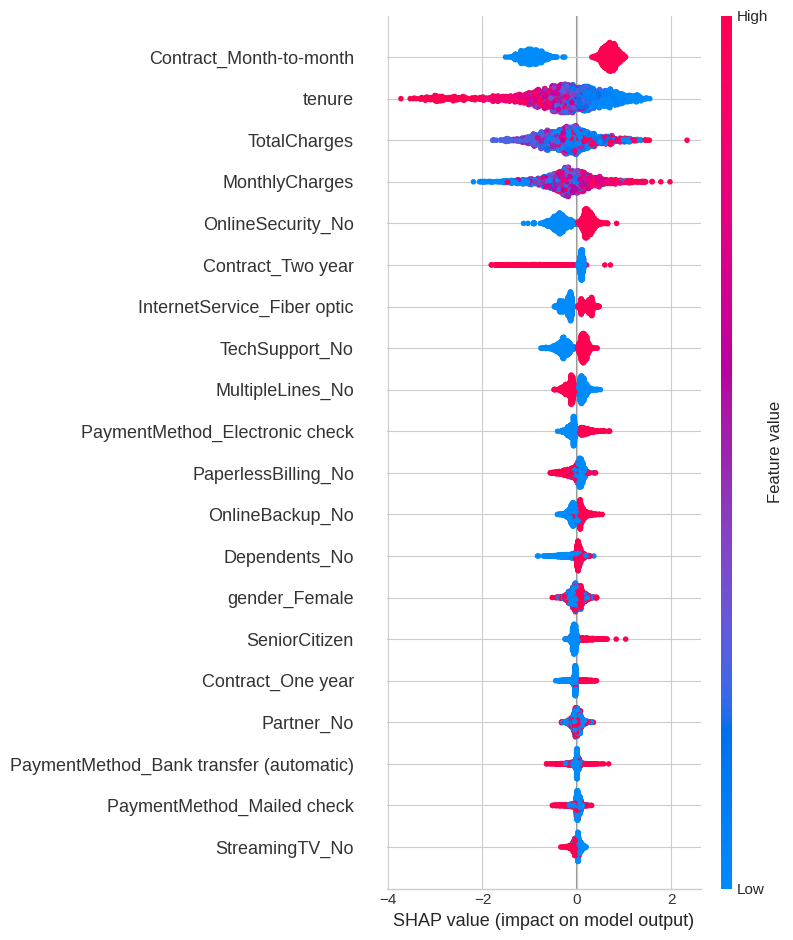

In [25]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_processed)

# График 1: Глобальная важность (аналог предыдущих графиков)
print("\nГрафик 1: Глобальная важность")
shap.summary_plot(shap_values, X_test_processed, feature_names=feature_names, plot_type="bar")

# График 2: Beeswarm plot (самый информативный)
print("\nГрафик 2: Распределение влияния признаков (Beeswarm plot)")
shap.summary_plot(shap_values, X_test_processed, feature_names=feature_names)

*Как читать второй график?*

Каждая точка — это один клиент из тестовой выборки.
Ось X — это SHAP value.

Положительные значения означают, что признак повысил вероятность оттока, отрицательные — понизил.

Цвет точки — это значение самого признака (красный — высокое, синий — низкое).
Анализ Contract_Month-to-month: Мы видим, что красные точки (значение признака = 1, т.е. контракт помесячный) имеют высокие положительные SHAP values. Это значит, что помесячный контракт сильно повышает вероятность оттока. Синие точки (значение = 0) имеют отрицательные SHAP values, т.е. другой тип контракта снижает вероятность оттока.

Анализ tenure (срок жизни клиента): Красные точки (большой срок) имеют отрицательные SHAP values (снижают риск оттока), а синие (маленький срок) — положительные (повышают риск оттока).
